<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/social_media/Topic_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries**

In [1]:
!pip install tweepy
!pip install gensim

In [2]:
# Importing Libraries - make sure the packages are installed
import os
import tweepy as tw
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# NLP
from wordcloud import WordCloud, STOPWORDS
import string
import nltk
from nltk import bigrams
from pathlib import Path
import random

#nltk library
nltk.download('punkt_tab')
nltk.download('stopwords')

from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

from nltk.corpus import stopwords as st
from nltk.tokenize import word_tokenize, sent_tokenize
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from gensim import corpora, models



import warnings
warnings.filterwarnings("ignore")

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **Loading Data**

In [3]:
# Reading data
%%time
FILE_ID = "1lhoPhOLB4fm-IgXlKhZFfC0UiFfHSklZ"
xlsx_url = f"https://docs.google.com/spreadsheets/d/{FILE_ID}/export?format=xlsx"
r = requests.get(xlsx_url)
df = pd.read_excel(BytesIO(r.content), engine="openpyxl")


CPU times: user 1min 56s, sys: 1.14 s, total: 1min 57s
Wall time: 2min 10s


In [4]:
df.head()

,Query Id,Query Name,Date,Title,Url,Domain,Sentiment,Page Type,Language,Country Code,Continent Code,Continent,Country,City Code,Account Type,Added,Assignment,Author,Category Details,Checked,City,Display URLs,Entity Info,Expanded URLs,Facebook Author ID,Facebook Comments,Facebook Likes,Facebook Role,Facebook Shares,Facebook Subtype,Full Name,Full Text,Gender,Impressions,Instagram Comments,Instagram Followers,Instagram Following,Instagram Interactions Count,Instagram Posts,Interest,Last Assignment Date,Latitude,Location Name,Longitude,Media Filter,Media URLs,Mentioned Authors,Original Url,Priority,Professions,Resource Id,Short URLs,Starred,Station Name,Viewership,Status,Subtype,Thread Author,Thread Created Date,Thread Entry Type,Thread Id,Thread URL,Total Monthly Visitors,X Author ID,X Channel Role,X Followers,X Following,X Replies,X Reply to,X Repost of,X Reposts,X Likes,X Posts,X Verified,Updated,Reach (new),Publication Name,Licenses,Redacted,Redacted Fields,Redaction Reason,Asset Content Id,Asset Thumb Id,Author Verified Type,Avatar,Batch Id,Blog Name,Broadcast Media Url,Is Syndicated,Air Type,Broadcast Type,Media Type,Ad Value,Circulation,Region,Region Code,Daily Visitors,Engagement Type,Hashtags,Item Review,Kicker,Linkedin Comments,Linkedin Engagement,Linkedin Impressions,Linkedin Likes,Linkedin Shares,Linkedin Sponsored,Linkedin Video Views,Parent Post Id,Parent Blog Name,Pub Type,Publisher Sub Type,Rating,Reddit Score,Reddit Score Upvote Ratio,Reddit Comments,Reddit Author Karma,Root Post Id,Root Blog Name,Subreddit,Subreddit Subscribers,Subscriptions,Sub Title,React Score Overall,React Score Emotionality,React Score Harmful,Engagement Score,Subreddit NSFW,Reddit Post Flair,Reddit Author Flair,Subreddit Topics,Reddit Spoiler,Publication Id,Page Type Name,Content Source,Content Source Name,Custom,Bluesky Author Id,Bluesky Followers,Bluesky Following,Bluesky Likes,Bluesky Posts,Bluesky Quotes,Bluesky Replies,Bluesky Reposts,Can Edit Markup,Can Edit Metadata,Can Edit Segmentation,Can Edit Workflow,Copyright,Factiva Attribute Code,Has Full Text,Impact,Instagram Likes,Mention Id,Podcast Audience Estimate,Podcast Duration Ms,Raw Metadata,Reportable,Threads Likes,Threads Quotes,Threads Replies,Threads Reposts,Threads Shares,Threads Views,Tiktok Comments,Tiktok Connected Account,Tiktok Likes,Tiktok Reach,Tiktok Shares,Tiktok Views,Weblog Title,Youtube Comments,Youtube Duration Milliseconds,Youtube Favourites,Youtube Likes,Youtube Subscriber Count,Youtube Video Count,Emotion
0,2003594270,Kenya protests 2025,2025-08-31 21:59:50.0,RT @_James041 Aden Duale is as guilty as F.\n\nGuy has tried ethical card and it has failed.\n\nSHA theft has affected everyone and no one wants to be associated with a thief.\n\nHe has tried hiring affordable bloggers and they have all been humbled by the truth.\n\nThe more a crocodile smiles the more his anus widens.\n\nThere's no escape route for the wicked!\n\n#DualeMustGo #RutoMustGo #DrainTheSwamp,http://twitter.com/kelvinngari62/statuses/1962274155270635732,twitter.com,negative,twitter,en,KEN,AFRICA,Africa,Kenya,KEN.Coast.Mombasa,individual,2025-09-02T09:16:47.214+0000,NaN,kelvinngari62,NaN,False,Mombasa,NaN,"{entityId=13414952, entityConfidence=HIGH, url=https://www.wikidata.org/wiki/Q13414952}, {entityId=43169, entityConfidence=MEDIUM, url=https://www.wikidata.org/wiki/Q43169}, {entityId=2727213, entityConfidence=MEDIUM, url=https://www.wikidata.org/wiki/Q2727213}, {entityId=4682154, entityConfidence=LOW, url=https://www.wikidata.org/wiki/Q4682154}, {entityId=497, entityConfidence=LOW, url=https://www.wikidata.org/wiki/Q497}",NaN,NaN,0,0,NaN,0,NaN,kelvinngari62 (knn),RT @_James041 Aden Duale is as guilty as F.\n\nGuy has tried ethical card and it has failed.\n\nSHA theft has affected everyone and no one wants to be associated with a thief.\n\nHe has tried hiring affordable bloggers and they have all been humbled by the truth.\n\nThe more a crocodile smiles the more his anus widens.\n\nThere's no e

# **Data Preprocessing**

In [5]:
df.columns

Index(['Query Id', 'Query Name', 'Date', 'Title', 'Url', 'Domain', 'Sentiment',
       'Page Type', 'Language', 'Country Code',
       ...
       'Tiktok Shares', 'Tiktok Views', 'Weblog Title', 'Youtube Comments',
       'Youtube Duration Milliseconds', 'Youtube Favourites', 'Youtube Likes',
       'Youtube Subscriber Count', 'Youtube Video Count', 'Emotion'],
      dtype='object', length=179)

In [6]:
# Convert 'Date' column to datetime format
df['tweet_date'] = pd.to_datetime(df['Date'], errors='coerce')

# June 2025 Tweets
df_final = df[(df['tweet_date'].dt.year == 2025) & (df['tweet_date'].dt.month == 6)]

In [7]:

# Clean function
def clean_text(text):
  """Takes a tweet, cleans it, lowercase and tokenises it.
  Input : string (text)
  Output: string (text)"""
  text = re.sub(r"http\S+|www\S+|https\S+", '', text)
  text = re.sub(r'\W+', ' ', text)
  text = text.lower()
  tokens = word_tokenize(text)
  tokens = [word for word in tokens if word not in stopwords.words('english')]
  return tokens

# Creating tokens
df_final['tokens'] = df_final['Title'].apply(clean_text)

# Hashtags function
def extract_hashtags(text):
  """Takes a tweet,extracts # (hashtags) from it.
  Input : string (text)
  Output: string (text)"""
  return re.findall(r"#\w+", text)

#extract hashtags
df_final['hashtags'] = df_final['Title'].apply(extract_hashtags)

# **Modelling**

In [8]:

# Bigrams function
def get_bigrams(tokens):
  """Takes a tokens,and create bigrams from it.
  Input : string (text)
  Output: string (text)"""

  return [' '.join(bg) for bg in bigrams(tokens)]

# create bigrams
df_final['bigrams'] = df_final['tokens'].apply(get_bigrams)

In [9]:

# Combine tokens and bigrams
df_final['combined'] = df_final['tokens'] + df_final['bigrams']

# Create dictionary and corpus
dictionary = corpora.Dictionary(df_final['combined'])
corpus = [dictionary.doc2bow(text) for text in df_final['combined']]

# Apply LDA
lda_model = models.LdaModel(corpus, num_topics = 7, id2word = dictionary, passes = 10)

## **Topics**

- Each of the 7 topics is visualised using individual word clouds, where the size of each word reflects its importance within that topic.
- Each word cloud will show the most important words in that topic. Bigger words = more important or frequent.



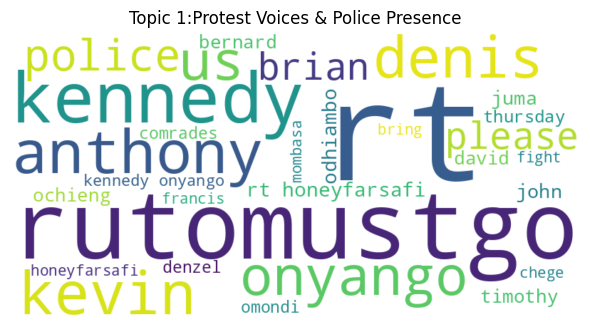

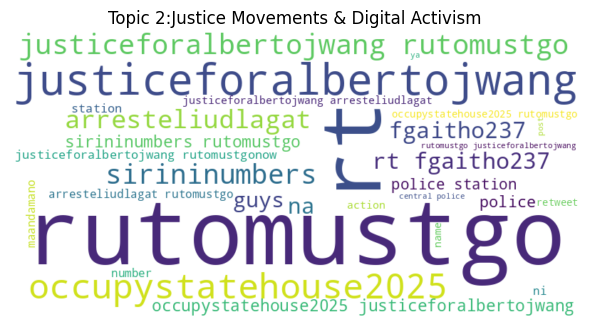

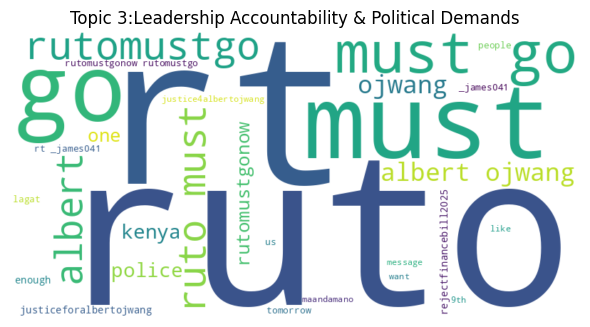

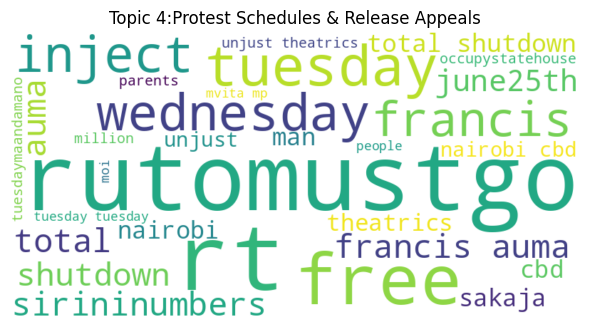

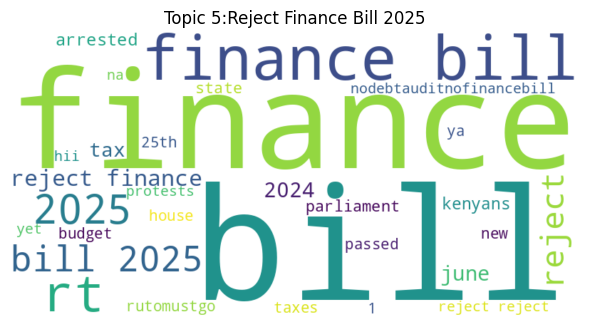

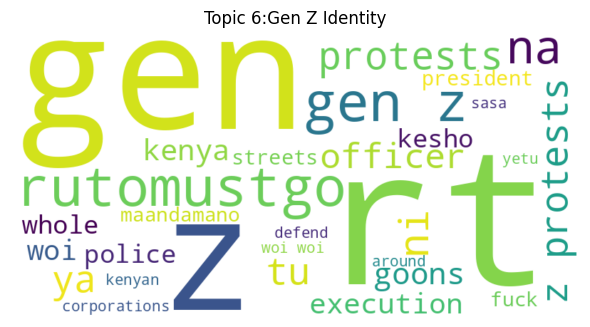

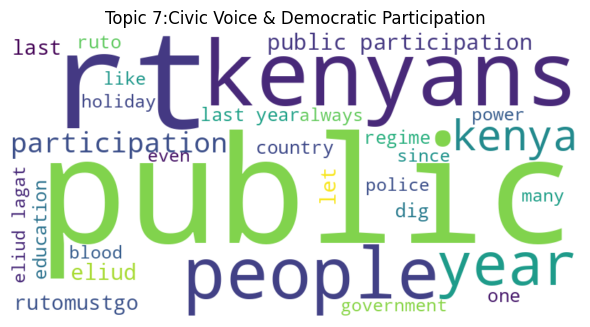

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

topics_labels = ['Protest Voices & Police Presence', 'Justice Movements & Digital Activism','Leadership Accountability & Political Demands'
                 ,'Protest Schedules & Release Appeals', 'Reject Finance Bill 2025','Gen Z Identity','Civic Voice & Democratic Participation']
# Loop through each topic
for i in range(7):
    topic_terms = lda_model.show_topic(i, topn=30)
    topic_words = {word: weight for word, weight in topic_terms}
    topic_title = topics_labels[i]
    # Generate word cloud
    wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(topic_words)

    # Display
    plt.figure(figsize=(6, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Topic {i+1}:{topic_title}")
    plt.tight_layout()
    plt.show()


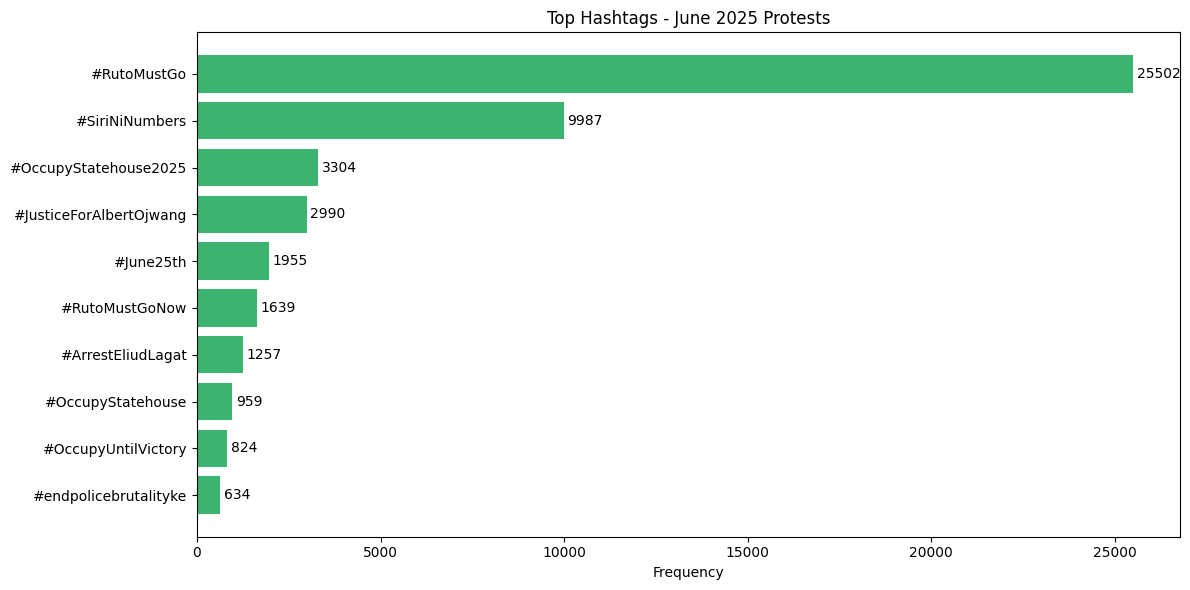

In [24]:
from collections import Counter
import matplotlib.pyplot as plt

hashtag_counts = Counter([tag for tags in df_final['hashtags'] for tag in tags])
top_hashtags = hashtag_counts.most_common(10)

tags, counts = zip(*top_hashtags)
# Create horizontal bar plot
plt.figure(figsize=(12, 6))
bars = plt.barh(tags, counts, color='mediumseagreen')
plt.xlabel("Frequency")
plt.title("Top Hashtags - June 2025 Protests")
plt.gca().invert_yaxis()
plt.tight_layout()

# Add labels to each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 100, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center', fontsize=10)

plt.show()

# **Analysis**

**Central Narrative: Leadership Rejection**:
- The dominance of #RutoMustGo and its variants (#RutoMustGoNow) across multiple topics reveals a unified call for political change.

- These hashtags act as rallying cries, uniting diverse grievances under a single demand: the resignation or removal of President Ruto.

**Justice and Accountability**:
- Hashtags like #JusticeForAlbertOjwang and #ArrestEliudLagat reflect personalized justice campaigns, often sparked by specific incidents of violence or injustice.

- These campaigns are amplified through digital activism, showing how individual stories encourage collective outrage.

**Policy-Specific Mobilisation**
Topic 5 ('Reject Finance Bill 2025') and hashtags like #RejectFinanceBill2025, show targeted resistance to legislation, particularly the Finance Bill.

- This suggests a politically motivated protest base engaging with governance beyond just leadership change.

**Youth-Led Identity**
- Topic 6 ('Gen Z Identity'), with keywords like gen z, na, ni, and z protests, captures the linguistic and cultural identity of young protesters.

- The use of slang in tweets and hashtags reflects a shift of generation in community engagement, with young people voicing over their opinion in national discourse.

**Collective Action & Participation**
- Topic 7 ('Civic Voice & Democratic Participation') emphasizes public participation, kenyans, and people, suggesting a broad-based civic awakening.

- Hashtags like #SiriNiNumbers (strength in numbers) and #OccupyUntilVictory reinforce the power of collective presence.

**Conclusion - Dynamics of Protest Discourse**

The June 2025 Kenyan protests were not just a spontaneous outburst — they were a digitally coordinated, multi-issue movement. The hashtag ecosystem reveals:

- A central unifying demand (#RutoMustGo)

- Localised justice campaigns that personalise the struggle.

- Policy-specific critiques that show political awareness.

- Youth-driven cultural expression shaping the tone and language.

- A strong emphasis on numbers, solidarity, and civic participation.
